In [36]:
import pandas as pd
import matplotlib.pyplot as plt

onion_name = "onion_preds.csv"
lstm_name = "lstm_preds.csv"
def filter_csv(filename):
    # Load the file and drop the second column
    df = pd.read_csv(filename)
    df = df.drop(columns=df.columns[1])  # drop 2nd column

    # Assign timestamp starting from Jan 1, 2024 00:00
    from datetime import timedelta

    # Get all zone names
    zones = df['zone'].unique()

    # Create empty list to store processed data
    processed = []

    # Build correct time-indexed data per zone
    for zone in zones:
        zdf = df[df['zone'] == zone].copy().reset_index(drop=True)
        zdf["timestamp"] = pd.date_range("2024-01-01", periods=len(zdf), freq="h")
        processed.append(zdf)

    # Concatenate all back
    df_time_aligned = pd.concat(processed, ignore_index=True)

    # Filter for the week August 12-19, 2024
    start = pd.Timestamp("2024-01-01")
    end = pd.Timestamp("2024-12-31")
    mask = (df_time_aligned["timestamp"] >= start) & (df_time_aligned["timestamp"] < end)

    # Zones to plot
    zones_of_interest = ["CZ"]
    processed = df_time_aligned[mask & df_time_aligned["zone"].isin(zones_of_interest)]
    return processed.drop(['zone'], axis = 1)

In [38]:
lr_preds    = pd.read_csv("lr_preds.csv", parse_dates=["timestamp"])
lstm_preds  = filter_csv(lstm_name)
onion_preds = filter_csv(onion_name)
lr_preds.head()


,timestamp,Linear Regression
0,2024-01-01 00:00:00,3.776501
1,2024-01-01 01:00:00,-2.497198
2,2024-01-01 02:00:00,0.080746
3,2024-01-01 03:00:00,2.248226
4,2024-01-01 04:00:00,1.810918


In [39]:
# Assume you have three DataFrames: df1, df2, df3
# Merge them on "timestamp"
merged = lr_preds.merge(lstm_preds, on="timestamp").merge(onion_preds.drop(["actual"], axis = 1), on="timestamp")
merged = merged.rename(columns={"actual": "Real Values"})

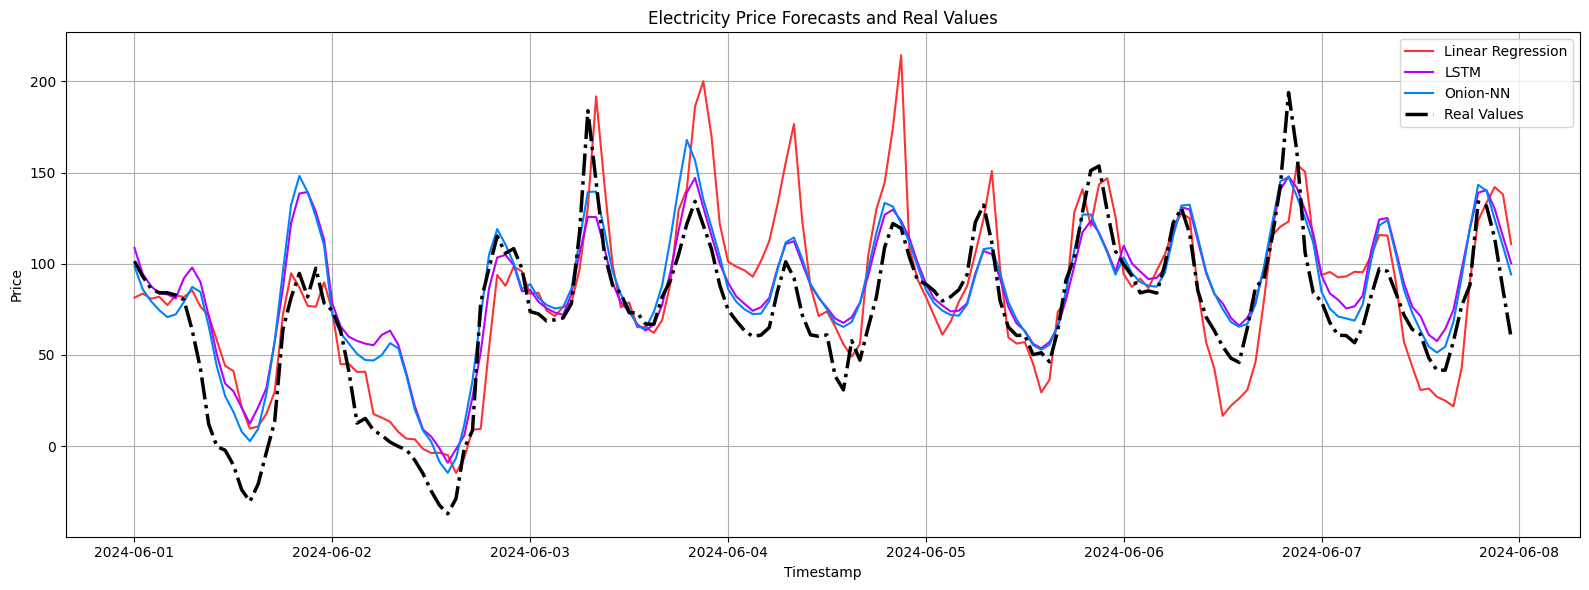

In [42]:
import matplotlib.pyplot as plt

# Load the final merged DataFrame from previous context
df_all = merged.copy()

# Assuming you already merged the full dataset into df_all
# Filter for the week 1-7 June 2024
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
week_df = df_all[(df_all["timestamp"] >= "2024-06-01") & (df_all["timestamp"] < "2024-06-08")]

# Plotting
plt.figure(figsize=(16, 6))
plt.plot(week_df["timestamp"], week_df["Linear Regression"], label = "Linear Regression", c="#ff3131")
plt.plot(week_df["timestamp"], week_df["LSTM"], label = "LSTM", c="#b700ff" )
plt.plot(week_df["timestamp"], week_df["Onion-NN"], label = "Onion-NN", c="#0082fc")
plt.plot(week_df["timestamp"], week_df["Real Values"], label = "Real Values", linestyle = "-.", lw=2.5, c="#000000")
plt.title("Electricity Price Forecasts and Real Values")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.xticks(rotation = 45)
plt.show()


In [37]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

# Load and prepare
df = pd.read_csv("CZ.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# 1. Prepare lag features
for lag in range(1, 25):
    df[f"lag_{lag}"] = df["Day-ahead Price"].shift(lag)

# 2. Split train/test
train_df = df[df["timestamp"] < "2024-01-01"]
test_df  = df[df["timestamp"] >= "2024-01-01"].dropna()

feature_cols = [f"lag_{i}" for i in range(1, 25)]

X_train = train_df[feature_cols]
y_train = train_df["Day-ahead Price"]

# Drop rows with NaNs in any column
mask = X_train.notna().all(axis=1) & y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

# Fit model
model = LinearRegression().fit(X_train, y_train)

# 4. Predict all of 2024 with rolling window
forecast_rows = []
for idx, row in test_df.iterrows():
    x_input = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
    y_pred = model.predict(x_input)[0]
    forecast_rows.append({"timestamp": row["timestamp"], "Linear Regression": y_pred})

# Save
df_preds = pd.DataFrame(forecast_rows)
df_preds.to_csv("lr_preds.csv", index=False)
